In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns

# Importing Models of sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
# Import Evaluation Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [2]:
df=pd.read_csv("heart.csv")
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [4]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

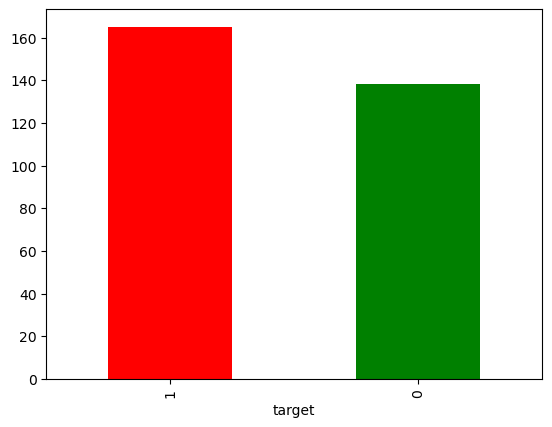

In [5]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar', color=['red','green'])
plt.show()


In [6]:
df.isna().sum() #missing values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [9]:
len(df)

303

In [10]:
# 0>female
# 1>male
pd.crosstab(df.target,df.sex)

sex,0,1
target,,
0,24,114
1,72,93


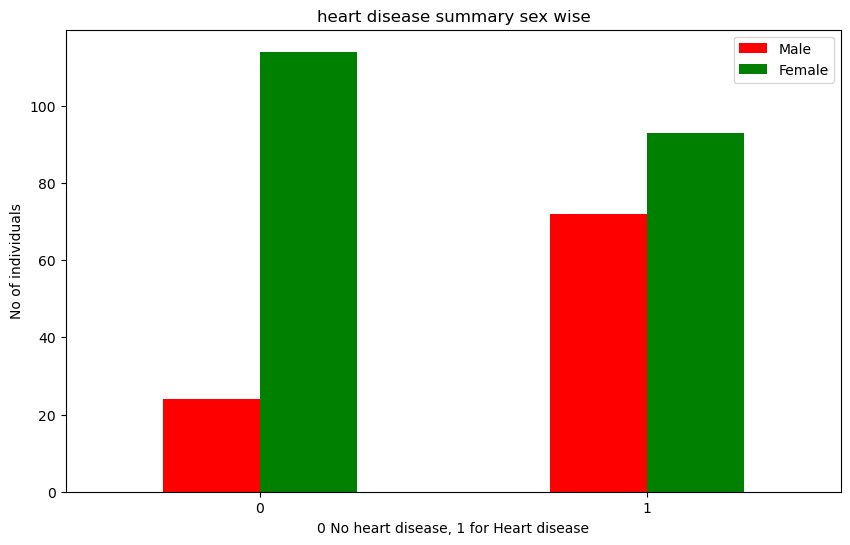

In [11]:

pd.crosstab(df.target,df.sex).plot(kind="bar",
                                   figsize=(10,6),
                                   color=["red","green"])
plt.title("heart disease summary sex wise")
plt.xlabel("0 No heart disease, 1 for Heart disease")
plt.ylabel("No of individuals")
plt.legend(["Male","Female"]);
plt.xticks(rotation=0)
plt.show()

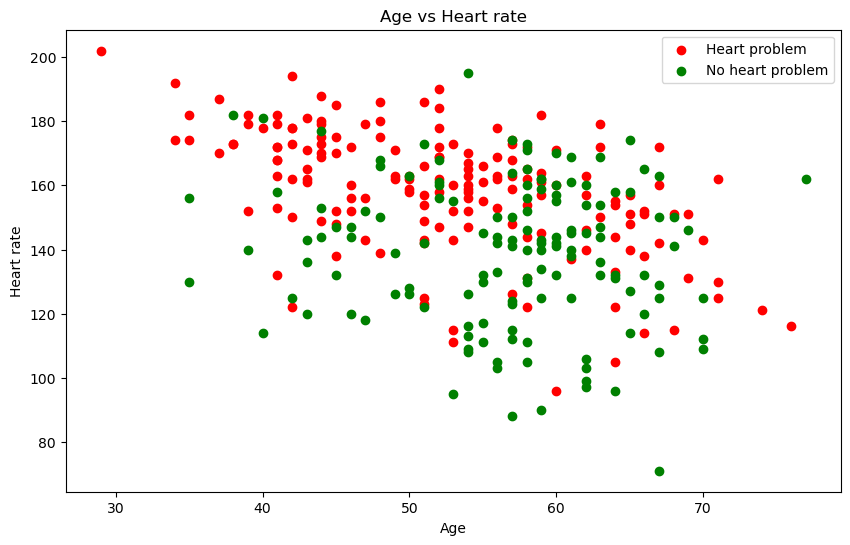

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(df.age[df.target==1],df.thalach[df.target==1],c="Red");
plt.scatter(df.age[df.target==0],df.thalach[df.target==0],c="green");
plt.title("Age vs Heart rate")
plt.ylabel("Heart rate")
plt.xlabel("Age")
plt.legend(["Heart problem", "No heart problem"])
plt.show()

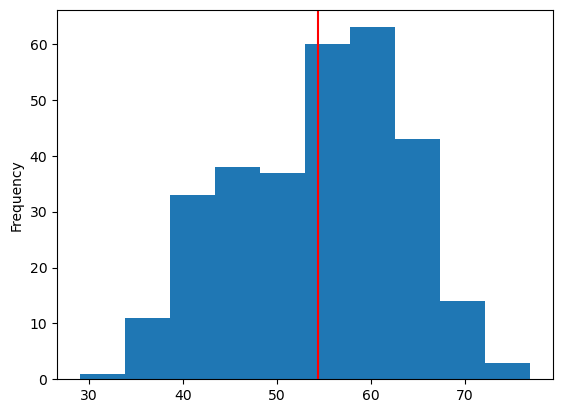

In [13]:
df.age.plot.hist();
plt.axvline(x=df.age.mean(),color="red")
plt.show()

In [14]:
df.cp.value_counts()

cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64

****************************** cp: chest pain type (Search UCI heart disease)
* Value 0: typical angina: Chest pain dues to decrease blood pressure
* Value 1: atypical angina: Chest Pain not related to Heart Problem
* Value 2: non-anginal pain: Not Heart Related
* Value 3: asymptomatic: Chest Paint not showing Heart Problem

In [15]:
pd.crosstab(df.cp,df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


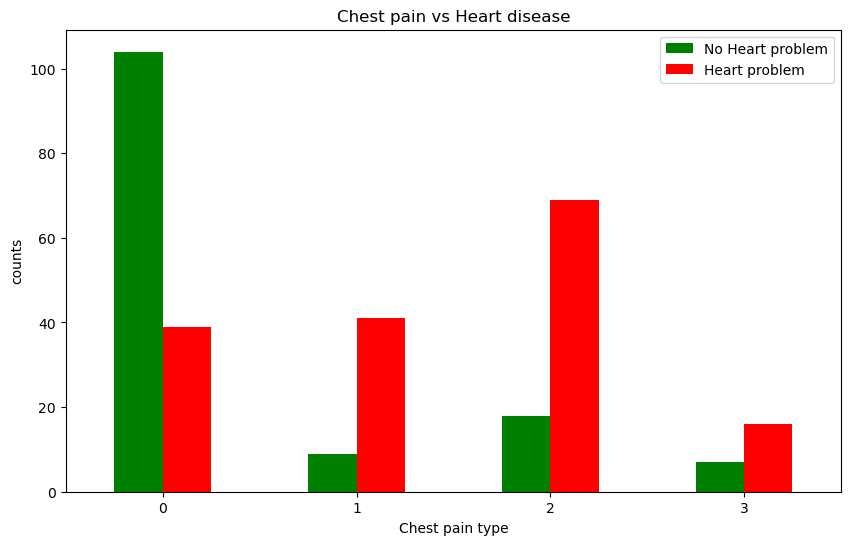

In [16]:
# Chest pain vs target
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(10,6),color=["Green","Red"])
plt.title("Chest pain vs Heart disease")
plt.xlabel("Chest pain type")
plt.ylabel("counts")
plt.legend(["No Heart problem","Heart problem"])
plt.xticks(rotation=0)
plt.show()

In [17]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


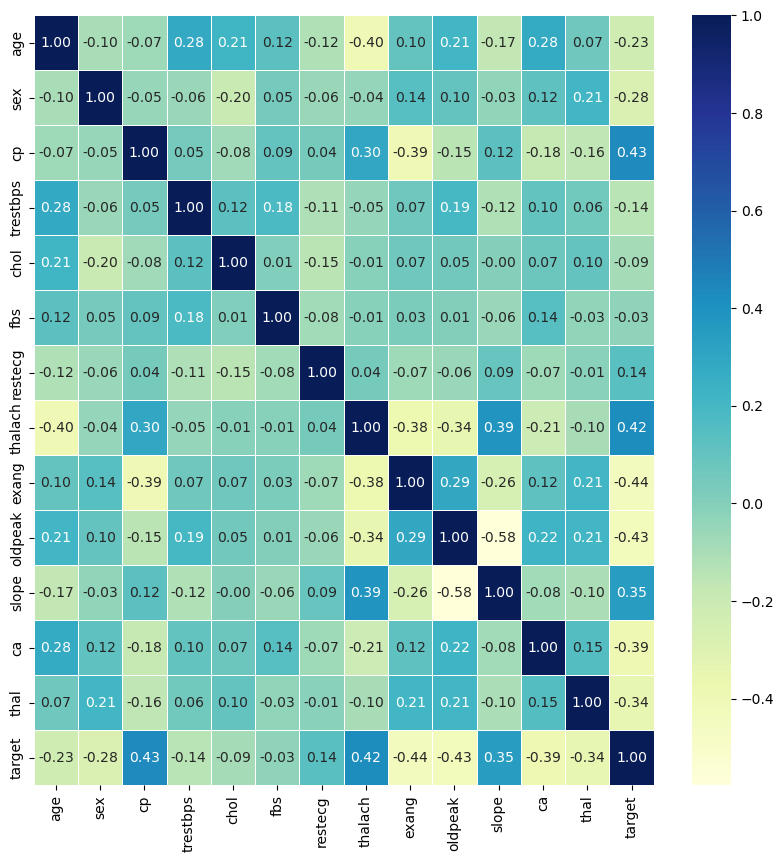

In [18]:
#Lets Draw Corelation Map
cor_map= df.corr()
home, room = plt.subplots (figsize=(10,10))
room = sns.heatmap(cor_map,
                   annot=True,
                   linewidths=0.5,
                   fmt="0.2f",
                   cmap="YlGnBu");
plt.show()

In [19]:
# SPLit into test and train data
X = df.drop("target", axis=1)
y = df["target"]


In [20]:
# Using Random seed, so that others could produce the same result
np.random.seed (7)
# Split into test and train Data
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size=0.2)


In [21]:
len(X), len(X_train)


(303, 242)

## The Models we are going to Use
* 1.K-Nearest Neighbours Classifier
* 2. Random Forest Classifier
* 3. Logistic Regression

In [22]:
# Putting the models into a Dictionary
models = {"KNN": KNeighborsClassifier(),
          "Random ": RandomForestClassifier(),
          "Logistic Regression":LogisticRegression()}

#Create Function to evaluate the models

def fit_and_score(models, X_train, X_test,y_train, y_test):
    np.random.seed(7)
    # make a Dictionary to score the model
    model_score = {}
    # Looping through
    for name, model in models.items():
        model.fit(X_train,y_train)
        # Evaluate the model and append it scode
        model_score[name] = model.score(X_test,y_test)
    return model_score

In [23]:
model_scores= fit_and_score(models=models,
                            X_train=X_train,
                            X_test=X_test,
                            y_train=y_train,
                            y_test=y_test)
model_scores

C:\Users\wsew\Desktop\AI-course\cardio_project_1\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.5573770491803278,
 'Random ': 0.7213114754098361,
 'Logistic Regression': 0.7377049180327869}

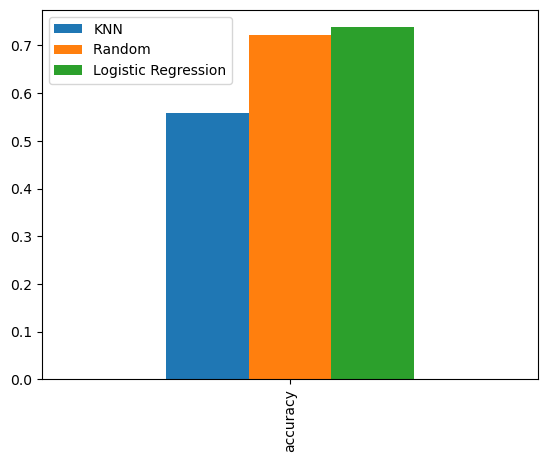

In [24]:
model_compare=pd.DataFrame(model_scores,index=["accuracy"])
model_compare.plot.bar();
plt.show()

# Imporving and Tuning the Model
Universal Methods used for all Classifications problems
* Hyperparameter Tunning
* Features Improving
## Advanced Level
* Confusion Matrix
* Cross_validation
Precision
* Recall
* f1
* Classification Report
* ROC Curve

In [25]:
KNN=KNeighborsClassifier()
KNN.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [26]:
train_score = []
test_score= []
# Create range to be test for n_neighbors
nneighbours = range(1,30)
#KNN Instance
KNN = KNeighborsClassifier()
# Looping though the range
for i in nneighbours:
    KNN.set_params(n_neighbors=i)
    # Run the fit for ith value 
    KNN.fit(X_train,y_train)
    # Update the Trsaining Score
    train_score.append(KNN.score (X_train,y_train))
    # Update the test score List
    test_score.append(KNN.score (X_test,y_test));

In [27]:
train_score

[1.0,
 0.8099173553719008,
 0.7768595041322314,
 0.756198347107438,
 0.7603305785123967,
 0.731404958677686,
 0.743801652892562,
 0.7148760330578512,
 0.71900826446281,
 0.731404958677686,
 0.7272727272727273,
 0.7231404958677686,
 0.731404958677686,
 0.71900826446281,
 0.7148760330578512,
 0.6900826446280992,
 0.7272727272727273,
 0.71900826446281,
 0.7107438016528925,
 0.7066115702479339,
 0.7024793388429752,
 0.7024793388429752,
 0.7107438016528925,
 0.6900826446280992,
 0.7107438016528925,
 0.7066115702479339,
 0.7107438016528925,
 0.7066115702479339,
 0.7066115702479339]

In [28]:
test_score

[0.6065573770491803,
 0.6557377049180327,
 0.6229508196721312,
 0.6229508196721312,
 0.5573770491803278,
 0.639344262295082,
 0.6721311475409836,
 0.6557377049180327,
 0.6065573770491803,
 0.6065573770491803,
 0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6557377049180327,
 0.6557377049180327,
 0.6557377049180327,
 0.6721311475409836,
 0.6721311475409836,
 0.6557377049180327,
 0.6721311475409836,
 0.6721311475409836,
 0.6721311475409836,
 0.6721311475409836,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7049180327868853,
 0.6557377049180327]

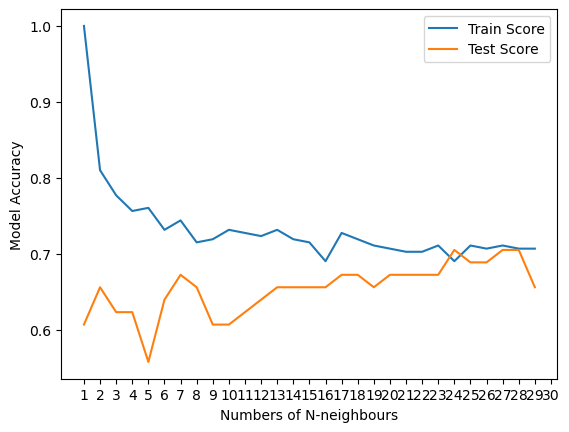

Max KNN Score: 70.49%


In [29]:
plt.plot(nneighbours, train_score, label="Train Score")
plt.plot(nneighbours, test_score, label="Test Score")
plt.xticks(np.arange(1,31,1))
plt.xlabel('Numbers of N-neighbours')
plt.ylabel('Model Accuracy')
plt.legend()
plt.show();
print(f"Max KNN Score: {max(test_score)*100:0.2f}%")

# Hyperparameter tunning using Randomized Search CV
* LogisticRegression()
* Random ForestClassifier()


In [30]:
LR_hp={
    "C": np.logspace(-4,4,20),
    "solver": ["liblinear"]
}
RFC_hp ={
    "n_estimators": np.arange(10,1600,100),
    "max_depth":[None, 3,5,6,10],
    "min_samples_split": np.arange(2,20,2),
    "min_samples_leaf":np.arange(1,20,2)
}

### 'ΚΝΝ': 0.5573770491803278, We have already dropped it
### 'Random Forest': 0.7213114754098361, After Hyperparamter Tunning = 0.7049180327868853
### 'Logistic Regression': 0.7377049180327869) after Hyperparameter Tuning (both gscv and rscv) = 0.7540983606557

* 1. By Hand Hyperparameter Tunning # Done it been there, seen it all
* 2. Randomized Search CV # Done it been there, seen it all
* 3. GridSearch CV # Lets try this one

In [34]:
#Tune logistic regression using GridSearch CV
np.random.seed (7)
#Lets Use RSCV to tune HP
lr_gs = GridSearchCV(LogisticRegression(n_jobs=1),
                        param_grid=LR_hp,
                        cv=5,
                        verbose=True)
# Fit the ramdon HP search model for LR
lr_gs.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression(n_jobs=1)
,param_grid,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [35]:
lr_gs.score(X_test,y_test)

0.7540983606557377

# random forest using grid search cv

In [38]:
#Plotting the Area unde the curve
y_preds = lr_gs.predict(X_test)


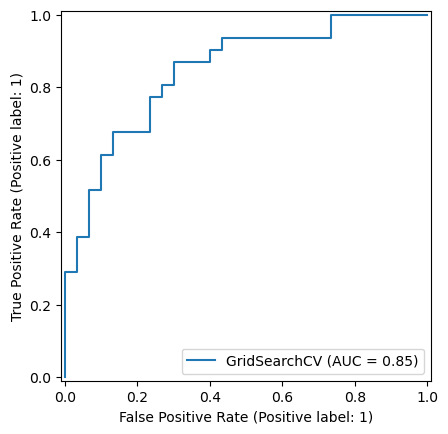

In [45]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr_gs, X_test, y_test)
plt.show()

In [46]:
#Confusion Matrix
print(confusion_matrix(y_test,y_preds))


[[18 12]
 [ 3 28]]


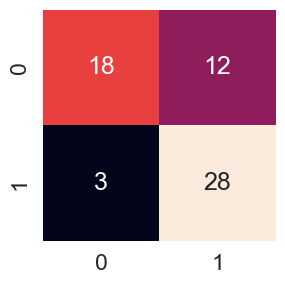

In [51]:
sns.set(font_scale=1.5)
def plot_confusion(y_test,y_preds): 
    "This is plot the confusion matrix"
    fig,ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(confusion_matrix(y_test,y_preds), 
                     annot=True,
                     cbar=False)
plot_confusion(y_test,y_preds)
plt.show()

In [52]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.86      0.60      0.71        30
           1       0.70      0.90      0.79        31

    accuracy                           0.75        61
   macro avg       0.78      0.75      0.75        61
weighted avg       0.78      0.75      0.75        61



In [53]:
lr_gs.best_params_
lr= LogisticRegression(C=0.615848211066026,
solver="liblinear")

In [54]:
#Cross Validated Accuracy
cv_accuracy = cross_val_score(lr,
                              X,
                              y,
                              cv=7,
                              scoring="accuracy")
cv_accuracy = np.mean(cv_accuracy)
cv_accuracy


np.float64(0.8284506191482934)

In [55]:
# Cross Validated precision
cv_precision= cross_val_score(lr,
                             X,
                             y,
                             cv=7,
                             scoring="precision")
cv_precision= np.mean(cv_precision)
cv_precision


np.float64(0.8108267922553637)

In [62]:
# Cross Validated precision
cv_recall= cross_val_score(lr,
                           X,
                           y,
                           cv=7,
                           scoring="recall")
cv_recall= np.mean(cv_recall)
cv_recall

np.float64(0.89648033126294)

In [63]:
# Cross Validated precision
cv_f1 =cross_val_score(lr,
                       X,
                       y,
                       cv=7,
                       scoring="f1")
cv_f1= np.mean(cv_f1)
cv_f1


np.float64(0.8508447334977947)

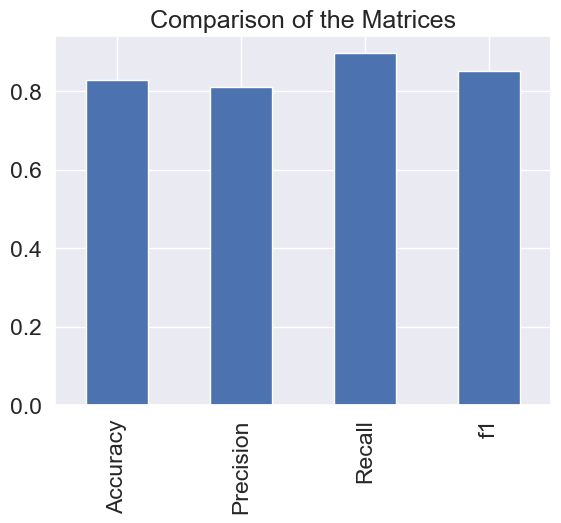

In [69]:
cv_plot= pd.DataFrame({
    "Accuracy":cv_accuracy,
    "Precision":cv_precision,
    "Recall":cv_recall,
    "f1":cv_f1
},index=[0])
cv_plot.T.plot.bar(title="Comparison of the Matrices",
                   legend=False)
plt.show()

## now features improvememnt

In [70]:
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.615848211066026
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [72]:
lr.coef_

array([[ 0.02258519, -1.36424618,  0.79069618, -0.02407434, -0.00186723,
         0.46020094,  0.40737683,  0.03558889, -0.78274542, -0.56757494,
         0.52792825, -0.64610992, -1.10640019]])

In [73]:
final_coef = dict(zip(df.columns, list(lr.coef_[0])))
final_coef

{'age': np.float64(0.02258518664970554),
 'sex': np.float64(-1.3642461816765101),
 'cp': np.float64(0.7906961820556367),
 'trestbps': np.float64(-0.024074344050095283),
 'chol': np.float64(-0.0018672296463649782),
 'fbs': np.float64(0.4602009443093141),
 'restecg': np.float64(0.4073768321684957),
 'thalach': np.float64(0.035588889531912235),
 'exang': np.float64(-0.78274542034898),
 'oldpeak': np.float64(-0.5675749432335981),
 'slope': np.float64(0.5279282517877898),
 'ca': np.float64(-0.6461099217862547),
 'thal': np.float64(-1.1064001887853232)}

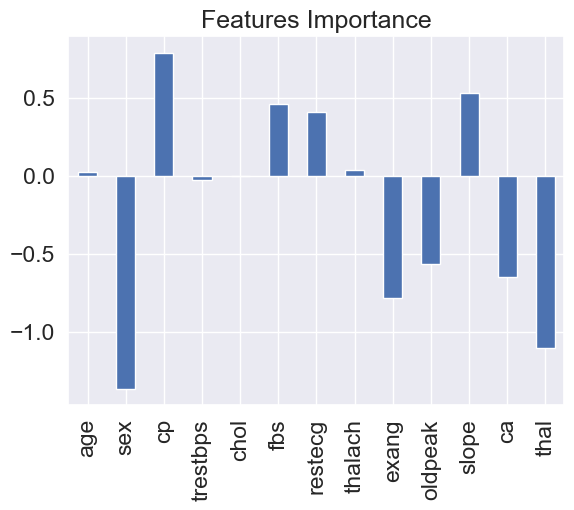

In [76]:
features = pd.DataFrame (final_coef, index=[0])
features.T.plot.bar(title="Features Importance", legend=False);
plt.show()